Building features...
Training Ensemble Models...

      LAB 5 EVALUATION: ENSEMBLE + 1.5x
Directional Accuracy      |         52.87%
MAE                       |       0.013241
RMSE                      |       0.018298
---------------------------------------------
Annualized Return         |         43.24%
Annualized Volatility     |         35.60%
Strategy Alpha            |         20.44%
Max Drawdown (MDD)        |        -39.56%
Sharpe Ratio              |         1.2146


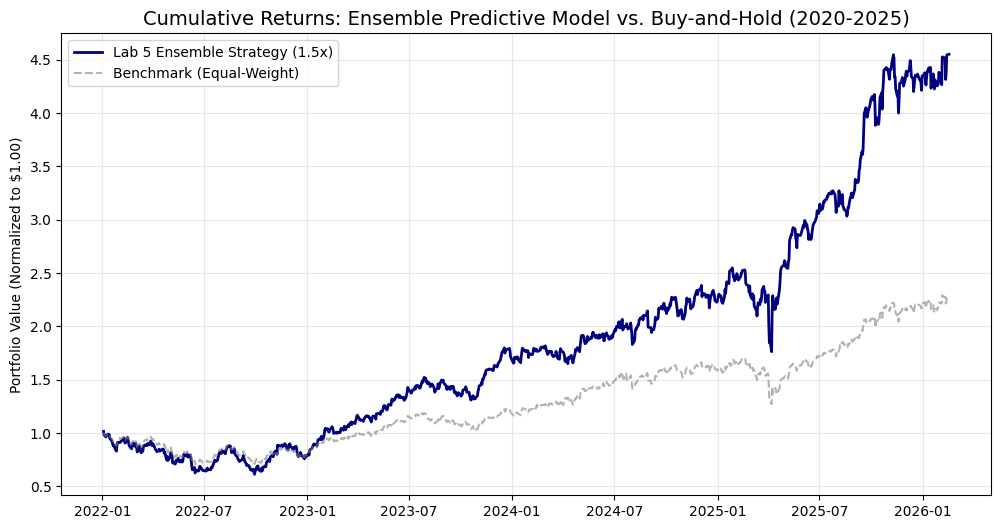

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVR
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. CONFIGURATION & HYPERPARAMETERS ---
TICKERS = ['AAPL', 'GE', 'PSCT']
START_DATE = "2010-01-01"
END_DATE = "2026-02-19"
MAX_LEVERAGE = 1.5  # Open Exploration choice for higher Annualized Return

# --- 2. DATA LOADING & ROBUST CLEANING ---
print(f"Downloading data for {TICKERS}...")
data = yf.download(TICKERS, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

all_list = []
for t in TICKERS:
    temp = pd.DataFrame()
    if isinstance(data.columns, pd.MultiIndex):
        temp['Close'] = data['Close'][t]
    else:
        temp['Close'] = data['Close']
    temp['ticker'] = t
    temp = temp.reset_index()
    all_list.append(temp)
df_raw = pd.concat(all_list)

# --- 3. FEATURE ENGINEERING (Indicators) ---
def build_features(group):
    group = group.sort_values('Date').copy()
    # Target: Next-day return
    group['target_ret'] = group['Close'].pct_change().shift(-1)

    # Technical Indicators
    group['ret_5d'] = group['Close'].pct_change(5)
    group['vol_5d'] = group['Close'].pct_change().rolling(5).std()
    group['vol_60d'] = group['Close'].pct_change().rolling(60).std()
    group['sma_ratio_20d'] = group['Close'] / group['Close'].rolling(20).mean()

    return group.dropna()

print("Building features...")
all_df = df_raw.groupby("ticker", group_keys=False).apply(build_features)
benchmark_daily = all_df.groupby('Date')['target_ret'].mean()

# --- 4. TRAIN/TEST SPLIT ---
train_df = all_df[all_df['Date'] < '2022-01-01']
test_df = all_df[all_df['Date'] >= '2022-01-01'].copy()

features = ['ret_5d', 'vol_5d', 'vol_60d', 'sma_ratio_20d']
X_train, y_train = train_df[features], train_df['target_ret']
X_test = test_df[features]

# --- 5. ENSEMBLE MODEL (Ridge + SVR) ---
# Ridge from Lab 4 (Alpha=100) + Linear SVR for Lab 5 (C=0.1)
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=100.0))])
svr_pipe = Pipeline([('scaler', StandardScaler()), ('svr', LinearSVR(C=0.1, random_state=42, max_iter=20000))])

print("Training Ensemble Models...")
ridge_pipe.fit(X_train, y_train)
svr_pipe.fit(X_train, y_train)

# Blend predictions 50/50
test_df['pred_ret'] = (ridge_pipe.predict(X_test) + svr_pipe.predict(X_test)) / 2

# --- 6. PREDICTION EVALUATION METRICS ---
actual_rets = test_df['target_ret']
predicted_rets = test_df['pred_ret']

mae = mean_absolute_error(actual_rets, predicted_rets)
rmse = np.sqrt(mean_squared_error(actual_rets, predicted_rets))
directional_acc = (np.sign(actual_rets) == np.sign(predicted_rets)).mean()

# --- 7. WEIGHTING & STRATEGY CALCULATION ---
def apply_leverage_weights(x):
    total_abs_weight = x.abs().sum()
    if total_abs_weight == 0: return 0
    return (x / total_abs_weight) * MAX_LEVERAGE

test_df['weight'] = test_df.groupby('Date')['pred_ret'].transform(apply_leverage_weights)
test_df['strategy_ret'] = test_df['weight'] * test_df['target_ret']
strat_daily = test_df.groupby('Date')['strategy_ret'].sum()

# --- 8. PORTFOLIO PERFORMANCE METRICS ---
ann_ret = strat_daily.mean() * 252
ann_vol = strat_daily.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol
alpha = ann_ret - (benchmark_daily.loc[strat_daily.index].mean() * 252)

cum_ret = (1 + strat_daily).cumprod()
mdd = ((cum_ret - cum_ret.cummax()) / cum_ret.cummax()).min()

# --- 9. FINAL OUTPUT TABLE ---
print("\n" + "="*45)
print(f"      LAB 5 EVALUATION: ENSEMBLE + {MAX_LEVERAGE}x")
print("="*45)
print(f"{'Directional Accuracy':<25} | {directional_acc:>14.2%}")
print(f"{'MAE':<25} | {mae:>14.6f}")
print(f"{'RMSE':<25} | {rmse:>14.6f}")
print("-" * 45)
print(f"{'Annualized Return':<25} | {ann_ret:>14.2%}")
print(f"{'Annualized Volatility':<25} | {ann_vol:>14.2%}")
print(f"{'Strategy Alpha':<25} | {alpha:>14.2%}")
print(f"{'Max Drawdown (MDD)':<25} | {mdd:>14.2%}")
print(f"{'Sharpe Ratio':<25} | {sharpe:>14.4f}")
print("="*45)

# --- 10. PLOTTING ---
plt.figure(figsize=(12, 6))
strat_cum = (1 + strat_daily).cumprod()
bench_cum = (1 + benchmark_daily.loc[strat_daily.index]).cumprod()

plt.plot(strat_cum, label=f'Lab 5 Ensemble Strategy ({MAX_LEVERAGE}x)', color='navy', lw=2)
plt.plot(bench_cum, label='Benchmark (Equal-Weight)', color='gray', linestyle='--', alpha=0.6)
plt.title("Cumulative Returns: Ensemble Predictive Model vs. Buy-and-Hold (2020-2025)", fontsize=14)
plt.ylabel("Portfolio Value (Normalized to $1.00)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()